<a href="https://colab.research.google.com/github/Kieunhungtruong/Econometrics/blob/main/chart/residualplot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display:flex;flex-direction:column;align-items:center;justify-content:center;gap:10px;">
  <h1 style="text-align:center;font-size:26px;font-weight:bold;font-family:'Nunito';color:purple;">
    Biểu đồ phần dư
  </h1>
</div>

## Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [2]:
!pip install pyreadstat -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
import pyreadstat
from pathlib import Path

palette = ["#53b0ae", "#a31414", "#2b6999", "#e37000", "#b2c615", "#88837d", "#B3B3B3"]

# ── Thư mục lưu ảnh ──────────────────────────────────────
SAVE_DIR = Path("/content/drive/MyDrive/econometrics/figures/Chapter3")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {SAVE_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.3 MB/s eta 0:00:00
Figures will be saved to: /content/drive/MyDrive/econometrics/figures/Chapter3


## Đọc dữ liệu

In [3]:
df, meta = pyreadstat.read_dta(
    "/content/drive/MyDrive/econometrics/rawdata/migration_remittances_16_full.dta",
    encoding="latin1",
)

# Hồi quy OLS để lấy phần dư
X = sm.add_constant(df["remittances"])
model = sm.OLS(df["per_expenditure"], X).fit()
df["residuals"] = model.resid
print("Data loaded, residuals computed.")

Data loaded, residuals computed.


## Hàm lưu biểu đồ

Hàm `save_fig(fig_id, ext)` tự động lưu theo tên chuẩn trong sách:
- `fig_id` : ví dụ `"Fig3.2"`, `"Fig3.3"`  
- `ext` : `"png"` (mặc định) hoặc `"pdf"`

In [4]:
def save_fig(fig_id: str, ext: str = "png", dpi: int = 150):
    """Lưu figure hiện tại với tên chuẩn theo sách."""
    filename = SAVE_DIR / f"{fig_id}.{ext}"
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    print(f"Saved → {filename}")

---
## Hình 3.2 – Phần dư theo tiền gửi về (remittances)

Quan sát xem phần dư có dao động có hệ thống theo biến độc lập không.

Saved → /content/drive/MyDrive/econometrics/figures/Chapter3/Fig3.2_residual_vs_remittances.png


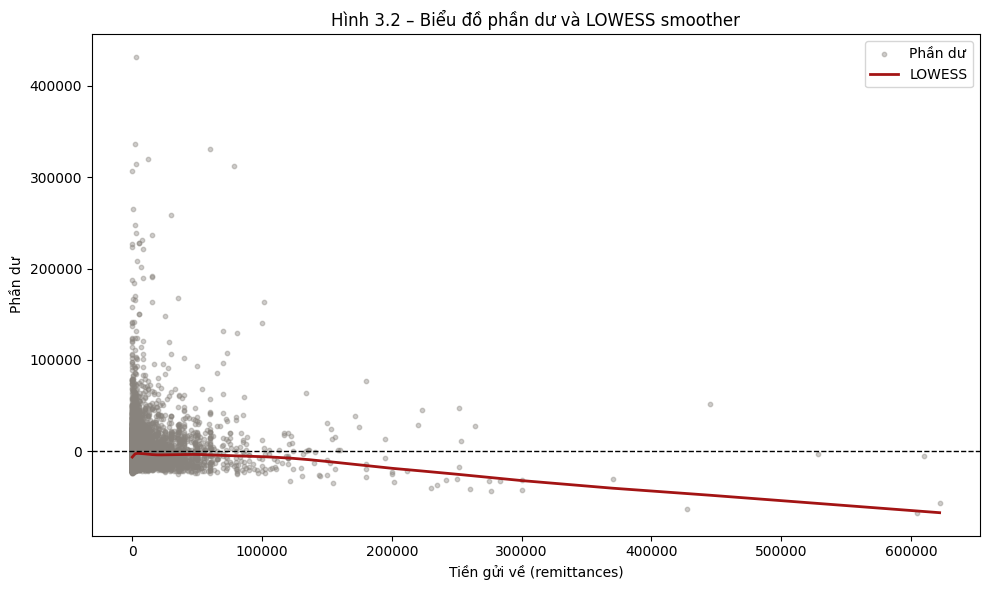

In [5]:
lowess_result = lowess(df["residuals"], df["remittances"])

plt.figure(figsize=(10, 6))
plt.scatter(
    df["remittances"], df["residuals"],
    color=palette[5], alpha=0.4, s=10, label="Phần dư"
)
plt.plot(
    lowess_result[:, 0], lowess_result[:, 1],
    color=palette[1], linewidth=2, label="LOWESS"
)
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Tiền gửi về (remittances)")
plt.ylabel("Phần dư")
plt.title("Hình 3.2 – Biểu đồ phần dư và LOWESS smoother")
plt.legend()
plt.tight_layout()
save_fig("Fig3.2_residual_vs_remittances")
plt.show()

<h2 style="font-size: 26px; font-weight: bold; font-family:'Nunito'; color: purple;">About the Authors:</h2>

<a href="https://www.linkedin.com/in/truongnhung2002"> Nhung Truong (Kristen Zhang) </a> has a degree in Investment Economics from UEH, with a focus on quantitative research.

## <h3 align="center"> © Nhung Truong. All rights reserved. </h3>